# Cross-Validation ROC/AUC
Stratified CV ROC curves and mean AUC.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

MODEL_DIR = 'random-forest'
MODEL_NAME = 'Random Forest'

cwd = Path.cwd()
project_root = Path("..").resolve() if cwd.name == MODEL_DIR else cwd
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from qspr_config import (
    DATA_PATH,
    ECFP_RADIUS,
    ECFP_N_BITS,
    N_ESTIMATORS,
    N_ESTIMATORS_GRID,
    TOP_N_BITS,
    RANDOM_SEED,
    TEST_SIZE,
    CV_FOLDS,
    N_JOBS,
    FIG_DPI,
    FIGSIZE_SQUARE,
    FIGSIZE_SQUARE,
)
from qspr_common import (
    load_dataset,
    build_feature_matrix,
    make_binary_target,
    apply_plot_style,
    resolve_output_dir,
)

apply_plot_style()
out_dir = resolve_output_dir(MODEL_DIR)


In [2]:
df = load_dataset(DATA_PATH)
df, X = build_feature_matrix(df, radius=ECFP_RADIUS, n_bits=ECFP_N_BITS)


[22:52:32] WARNING: not removing hydrogen atom without neighbors
[22:52:32] WARNING: not removing hydrogen atom without neighbors
[22:52:32] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:33] WARNING: not removing hydrogen atom without neighbors
[22:52:34] WARNING: not removing hydrogen atom without neighbors
[22:52:34] WARNING: not removing hydrogen atom without neighbors
[22:52:34] WARNING: not removing hydrogen atom without neighbors
[22:52:34] WARNING: not r

In [3]:
y, cutoff = make_binary_target(df["Solubility"].to_numpy())


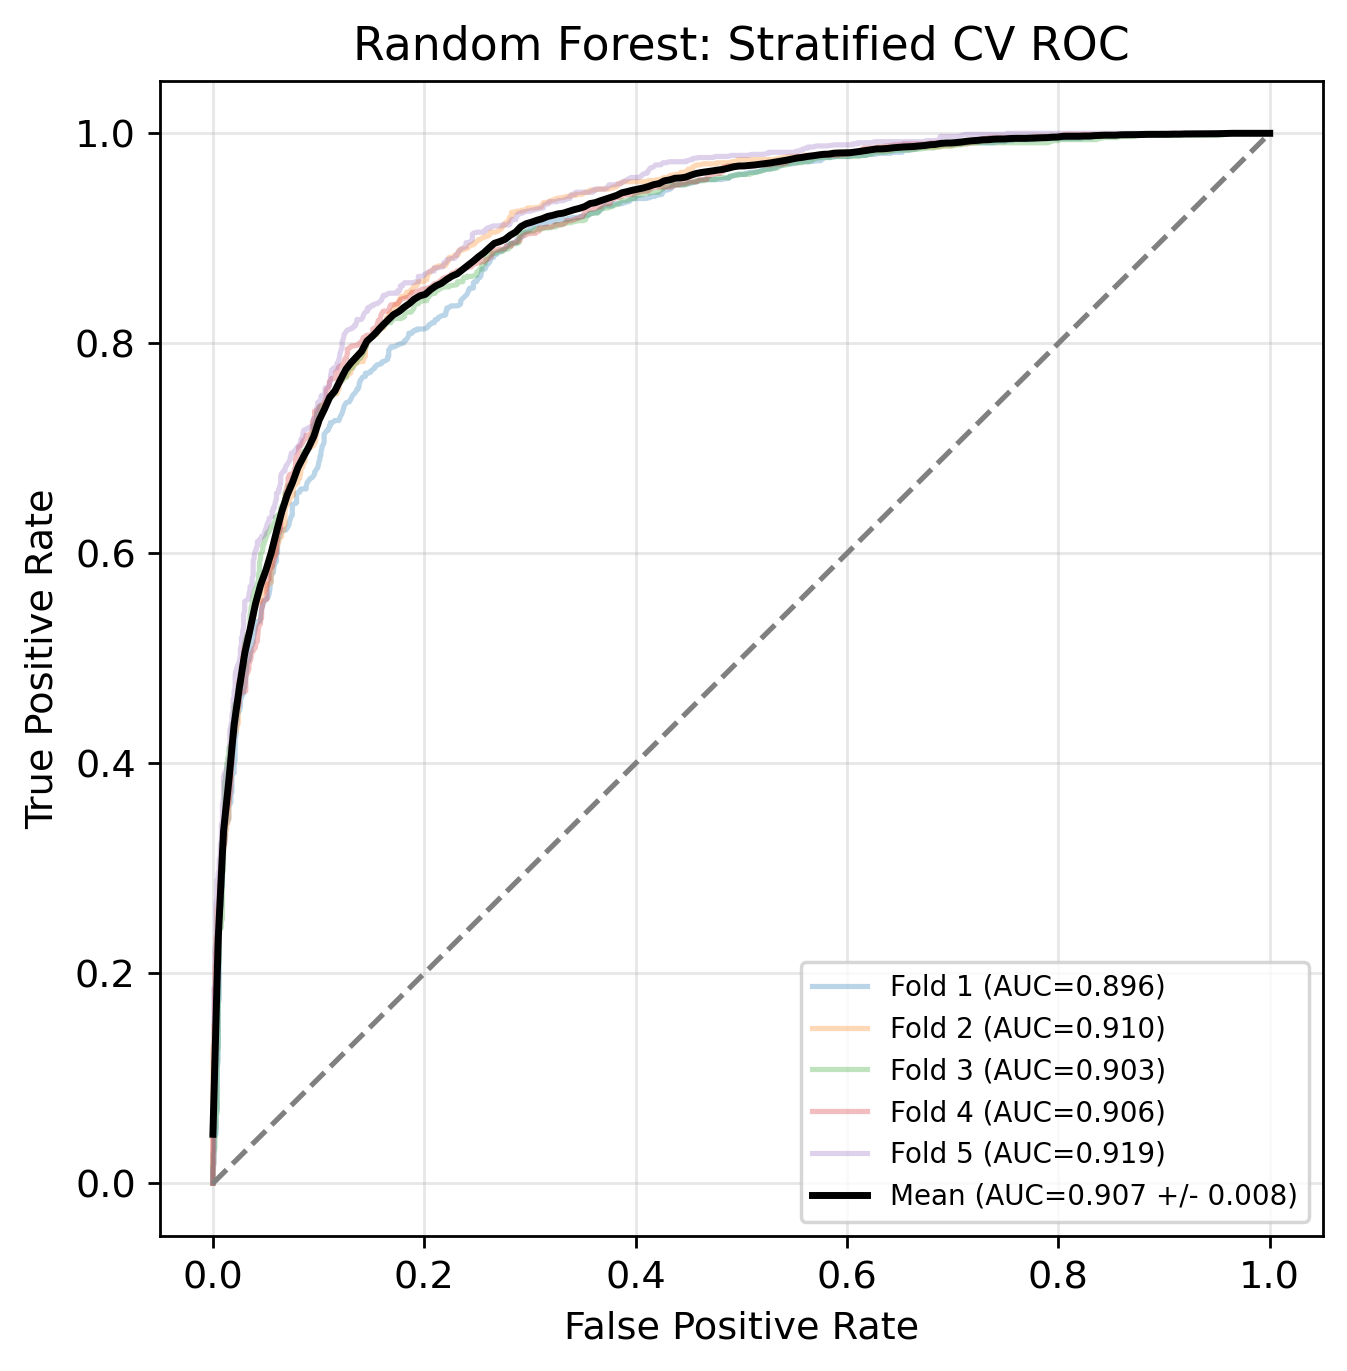

PosixPath('/Users/michael/dev/delta/qspr-explainability/qspr/random-forest/outputs/roc_cv_curve.png')

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

mean_fpr = np.linspace(0, 1, 200)
tprs = []
aucs = []

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    model = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_SEED,
        n_jobs=N_JOBS,
    )
    model.fit(X[train_idx], y[train_idx])
    probas = model.predict_proba(X[test_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y[test_idx], probas)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold_idx} (AUC={roc_auc:.3f})")
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    aucs.append(roc_auc)

tprs = np.asarray(tprs)
mean_tpr = tprs.mean(axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(
    mean_fpr,
    mean_tpr,
    color="black",
    lw=2,
    label=f"Mean (AUC={mean_auc:.3f} +/- {std_auc:.3f})",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"{MODEL_NAME}: Stratified CV ROC")
ax.legend(loc="lower right", fontsize=8)

out_path = out_dir / "roc_cv_curve.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
out_path
